# "Tipping points"

Many networks exhibit a "tipping point" property where a sharp phase transition occurs from local to global cascades as some parameter changes.

The parameters that we have examined which affect the nature of the cascade are:
* The standard deviation $\sigma$ of the threshold distribution function $f(\phi)$
* The size of the set of initially affected nodes $f^{IA}$ 

The value of the parameter which correlates with the tipping point in the cascade is referred to as the critical value.


In [2]:
import os
import glob
import math
import pickle
import numpy as np
import networkx as nx
from tqdm import tqdm
from utils import load_graph
import matplotlib.pyplot as plt
from heuristics import RND
from models import threshold_norm_special

## Identifying $f^{IA}_c$ for a set of standard deviations

In the following, we try to identify the critical fraction of initially infected nodes for facebook_combined with:
* normally distributed $\phi$
* standard deviations $\sigma \in [0.0001 : 0.29]$
* constant $\langle\phi\rangle$ = 0.5

We do this by calculating the normalized variance of the distribution of activated nodes:

$\frac{\frac{1}{N}\textstyle\sum_{i=1}^Nn_i²}{(\frac{1}{N}\textstyle\sum_{i=1}^Nn_i)²}, N = simulations per combination, ni = activated nodes in simulation i$

### Run simulations

In [ ]:
# Function to run a set of simulations and return the normalized susceptibility
def compute_susceptibility(fIA, std, mean, pbar, Nn):
    S = []
    
    n_seeds = int(fIA * Nn)

    for i in range(n_sims):
        seed = RND(G, n_seeds)
        activated = threshold_norm_special(G, seed, mean, threshold_std=std)
        S.append(len(activated)/float(Nn))

        # Update progress bar
        pbar.update(1)
        pbar.set_postfix(mean=f"{mean:.3f}", std=f"{std:.3f}", fIA=f"{fIA:.3f}")
    
    S = np.array(S)
    return np.mean(S**2) / np.mean(S)**2

# Graph and parameter setup
base_dir = "susceptibility_results"

G : nx.Graph = load_graph("datasets/wiki.txt")

Nn = len(G.nodes())

n_coarse_fIAs = 5          # Number of initial fractions to test in coarse scan; default 10
n_fine_fIAs = 0            # Number of initial fractions to test in fine scan; default 10
upper_fIA = 0.05            # Highest initial fraction to test; default 0.35
lower_fIA = 0.01           # Lowest initial fraction !! IMPORTANT !! Values less than ~0.02 seem to make susceptibility rocket
fIA_range = upper_fIA / n_coarse_fIAs   # +- from center on fine scan

n_means = 2                 # Number of means to test; default 4
u_mean = 0.5
l_mean = 0.4

n_stds = 4                 # Number of standard deviations to test; default 20
l_std = 0.05             # Lower bound of standard deviations; default 0.00001
u_std = 0.2               # Upper bound of standard deviations; default 0.288

n_sims = int(Nn/10)       # Number of simulations to run per combination; default Nn/10
total_sims = n_sims * (n_coarse_fIAs + n_fine_fIAs) * n_stds * n_means

# Evenly spaced std and mean values within range
threshold_stds = np.linspace(l_std, u_std, n_stds)
threshold_means = np.linspace(l_mean, u_mean, n_means)

# Setting up progress bar
pbar = tqdm(total=total_sims, desc="Total simulations")

# Prep for simulations
print(f"Graph size: {Nn}")
print(f"Running {total_sims} simulations")

# Running simulations
for mean_threshold in threshold_means:
    print(f"\n--- MEAN {mean_threshold:.3f} ---")

    # We make a new directory for the results in this mean
    mean_dir = os.path.join(base_dir, f"wiki_mean_{mean_threshold}")
    os.makedirs(mean_dir, exist_ok=True)

    for std in threshold_stds:
        print(f"\n--- STD {std:.5f} ---")

        # One file per std
        filename = os.path.join(mean_dir, f"std_{std:.5f}.pkl")

        if os.path.exists(filename):
            print(f"Skipping std={std}, file already exists")
            continue

        curve = {
            "std" : std,
            "mean" : mean_threshold,
            "fIA" : [],
            "Sus" : [],
            "type" : []
        }

        # ----- COARSE SCAN -----
        # We first do a "coarse" scan to identify the rough fIA that gives a high susceptibilty for the current std

        # Evenly spaced initial fraction values within range
        coarse_fIAs = np.linspace(lower_fIA, upper_fIA, n_coarse_fIAs)
        coarse_results = []

        for fIA in coarse_fIAs:
            # print(f"Coarse scan: std = {std:.5f}, fIA = {fIA:.4f}")
            
            sus = compute_susceptibility(fIA, std, mean_threshold, pbar, Nn)
            curve["fIA"].append(fIA)
            curve["Sus"].append(sus)
            curve["type"].append("coarse")
            coarse_results.append((fIA, sus))

        # Identify fIA with the highest susceptibility
        best_fIA, best_sus = max(coarse_results, key = lambda x: x[1])

        # print(f"Coarse peak at fIA ≈ {best_fIA:.4f}")

        # ----- FINE SCAN -----
        # Now we zoom in on the previously identified fIA and do a finer scan in its neighborhood for a precise susceptibility
        left = max(lower_fIA, best_fIA - fIA_range)
        right = min(upper_fIA, best_fIA + fIA_range)

        refined_fIAs = np.linspace(left, right, n_fine_fIAs)

        for fIA in refined_fIAs:
            # print(f"Refined scan: std = {std:.5f}, fIA = {fIA:.4f}")
            
            sus = compute_susceptibility(fIA, std, mean_threshold, pbar)
            curve["fIA"].append(fIA)
            curve["Sus"].append(sus)
            curve["type"].append("fine")

        # Pickle results
        with open(filename, "wb") as f:
            pickle.dump(curve, f)

        print (f"Saved results -> {filename}")

pbar.close()

Total simulations:   0%|          | 4/28440 [00:00<30:35, 15.49it/s, fIA=0.010, mean=0.400, std=0.050]

Graph size: 7115
Running 28440 simulations

--- MEAN 0.400 ---

--- STD 0.05000 ---


Total simulations:  13%|█▎        | 3560/28440 [02:36<18:54, 21.92it/s, fIA=0.010, mean=0.400, std=0.100]

Saved results -> susceptibility_results/wiki_mean_0.4/std_0.05000.pkl

--- STD 0.10000 ---


Total simulations:  25%|██▌       | 7113/28440 [05:24<19:49, 17.93it/s, fIA=0.010, mean=0.400, std=0.150]

...

Saved results -> susceptibility_results/wiki_mean_0.5/std_0.10000.pkl

--- STD 0.15000 ---


Total simulations:  88%|████████▊ | 24889/28440 [22:44<02:45, 21.42it/s, fIA=0.010, mean=0.500, std=0.200]

Saved results -> susceptibility_results/wiki_mean_0.5/std_0.15000.pkl

--- STD 0.20000 ---


Total simulations: 100%|██████████| 28440/28440 [26:16<00:00, 18.04it/s, fIA=0.050, mean=0.500, std=0.200]

Saved results -> susceptibility_results/wiki_mean_0.5/std_0.20000.pkl


### Simulations with discrete, small seed set sizes 

Results indicate that we see extremely high susceptibility with low values of fIA (start increasing below 1% ish) with some combinations of mean/std. BUT not necessarily always a correspondence of lower fIA : higher susceptibility. Therefore we want to rerun the susceptibility calculations with discrete seed set sizes of [1 : 10] instead of a fraction of total size. 

In [ ]:
# Function to run a set of simulations and return the normalized susceptibility
def compute_susceptibility(n_seeds, std, mean, pbar, Nn):
    S = []

    for i in range(n_sims):
        seed = RND(G, n_seeds)
        activated = threshold_norm_special(G, seed, mean, threshold_std=std)
        S.append(len(activated)/float(Nn))

        # Update progress bar
        pbar.update(1)
        pbar.set_postfix(mean=f"{mean:.3f}", std=f"{std:.3f}", n_seeds=f"{n_seeds}")
    
    S = np.array(S)
    return np.mean(S**2) / np.mean(S)**2

# Graph and parameter setup
base_dir = "susceptibility_results_discrete"

G : nx.Graph = load_graph("datasets/village.csv")

Nn = len(G.nodes())

n_seeds_list = range(4,10)     # List of seed set sizes to test; default 1 to 10 

n_means = 5                 # Number of means to test; default 4
u_mean = 0.2
l_mean = 0.6

n_stds = 6                  # Number of standard deviations to test; default 20
l_std = 0.000001            # Lower bound of standard deviations; default 0.000001
u_std = 0.288               # Upper bound of standard deviations; default 0.288

n_sims = int(Nn)       # Number of simulations to run per combination; default Nn/10
total_sims = n_sims * len(n_seeds_list) * n_stds * n_means

# Evenly spaced std and mean values within range
threshold_stds = np.linspace(l_std, u_std, n_stds)
threshold_means = np.linspace(l_mean, u_mean, n_means)

# Setting up progress bar
pbar = tqdm(total=total_sims, desc="Total simulations")

# Prep for simulations
print(f"Graph size: {Nn}")
print(f"Running {total_sims} simulations")

# Running simulations
for mean_threshold in threshold_means:
    print(f"\n--- MEAN {mean_threshold:.3f} ---")

    # We make a new directory for the results in this mean
    mean_dir = os.path.join(base_dir, f"village_mean_{mean_threshold}")
    os.makedirs(mean_dir, exist_ok=True)

    for std in threshold_stds:
        print(f"\n--- STD {std:.5f} ---")

        # One file per std
        filename = os.path.join(mean_dir, f"std_{std:.5f}.pkl")

        if os.path.exists(filename):
            print(f"Skipping std={std}, file already exists")
            continue

        curve = {
            "std" : std,
            "mean" : mean_threshold,
            "n_seeds" : [],
            "Sus" : []
        }

        for n_seeds in n_seeds_list:
            sus = compute_susceptibility(n_seeds, std, mean_threshold, pbar, Nn)
            curve["n_seeds"].append(n_seeds)
            curve["Sus"].append(sus)

        # Pickle results
        with open(filename, "wb") as f:
            pickle.dump(curve, f)

        print (f"Saved results -> {filename}")

pbar.close()

### Plot $f^{IA}$ curves

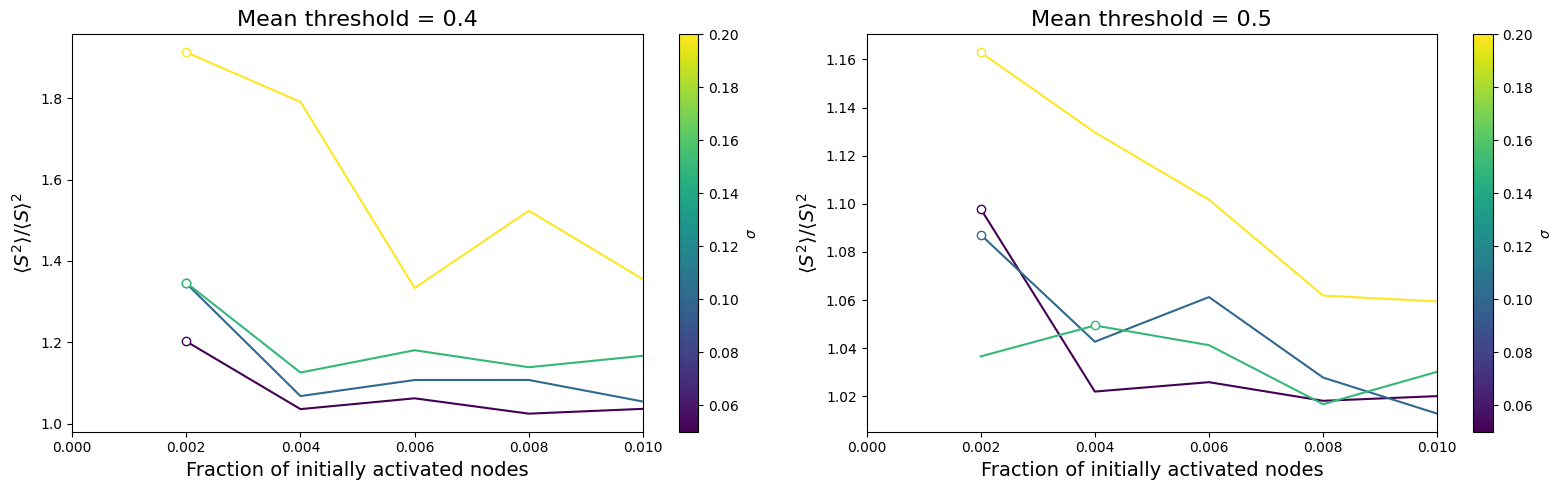

In [6]:
base_dir = "susceptibility_results"

# Find all mean folders
mean_dirs = sorted(glob.glob(os.path.join(base_dir, "fb_mean_*")))

# Setup for subplots
n_means = len(mean_dirs)
n_rows = math.ceil(n_means / 2)
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5*n_rows))
axes = axes.flatten()

# Color bar setup
cmap = plt.cm.viridis

# For fixing all x-axes to same limit
global_max_fIA = 0

# Each mean gets one graph
for ax, mean_dir in zip(axes, mean_dirs):

    # Setup filenames and sort by std value
    files = sorted(glob.glob(os.path.join(mean_dir, "std_*.pkl")))

    # Load data from files into curves list
    curves = []
    for file in files:
        with open(file, "rb") as f:
            curves.append(pickle.load(f))

    # Normalize std values for colorbar
    std_values = [curve["std"] for curve in curves]
    norm = plt.Normalize(min(std_values), max(std_values))

    for curve in curves:

        std = curve["std"]
        x = curve["fIA"]
        y = curve["Sus"]

        sorted_curves = np.argsort(x)
        x = np.array(x)[sorted_curves]
        y = np.array(y)[sorted_curves]

        # Update x-axis limit to max fIA so far 
        global_max_fIA = max(global_max_fIA, max(curve["fIA"]))

        #P Plot curve
        ax.plot(x, y, color=cmap(norm(std)))

        # Plot peak on curve
        peak = np.argmax(y)
        ax.plot(
            x[peak],
            y[peak],
            "-o",
            color=cmap(norm(std)),
            markerfacecolor="white"
        )

    # Extract mean value for title
    mean_val = os.path.basename(mean_dir).split("_")[-1]

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=ax, label=r"$\sigma$")

    ax.set_title(f"Mean threshold = {mean_val}", fontsize=16)

    ax.set_ylabel(r'$\langle S^2 \rangle / \langle S \rangle^2$', fontsize=14)
    ax.set_xlabel('Fraction of initially activated nodes', fontsize=14)

for ax in axes:
    ax.set_xlim(0, global_max_fIA)

plt.tight_layout()
plt.show()


### Viz for specific numbers of initially activated nodes

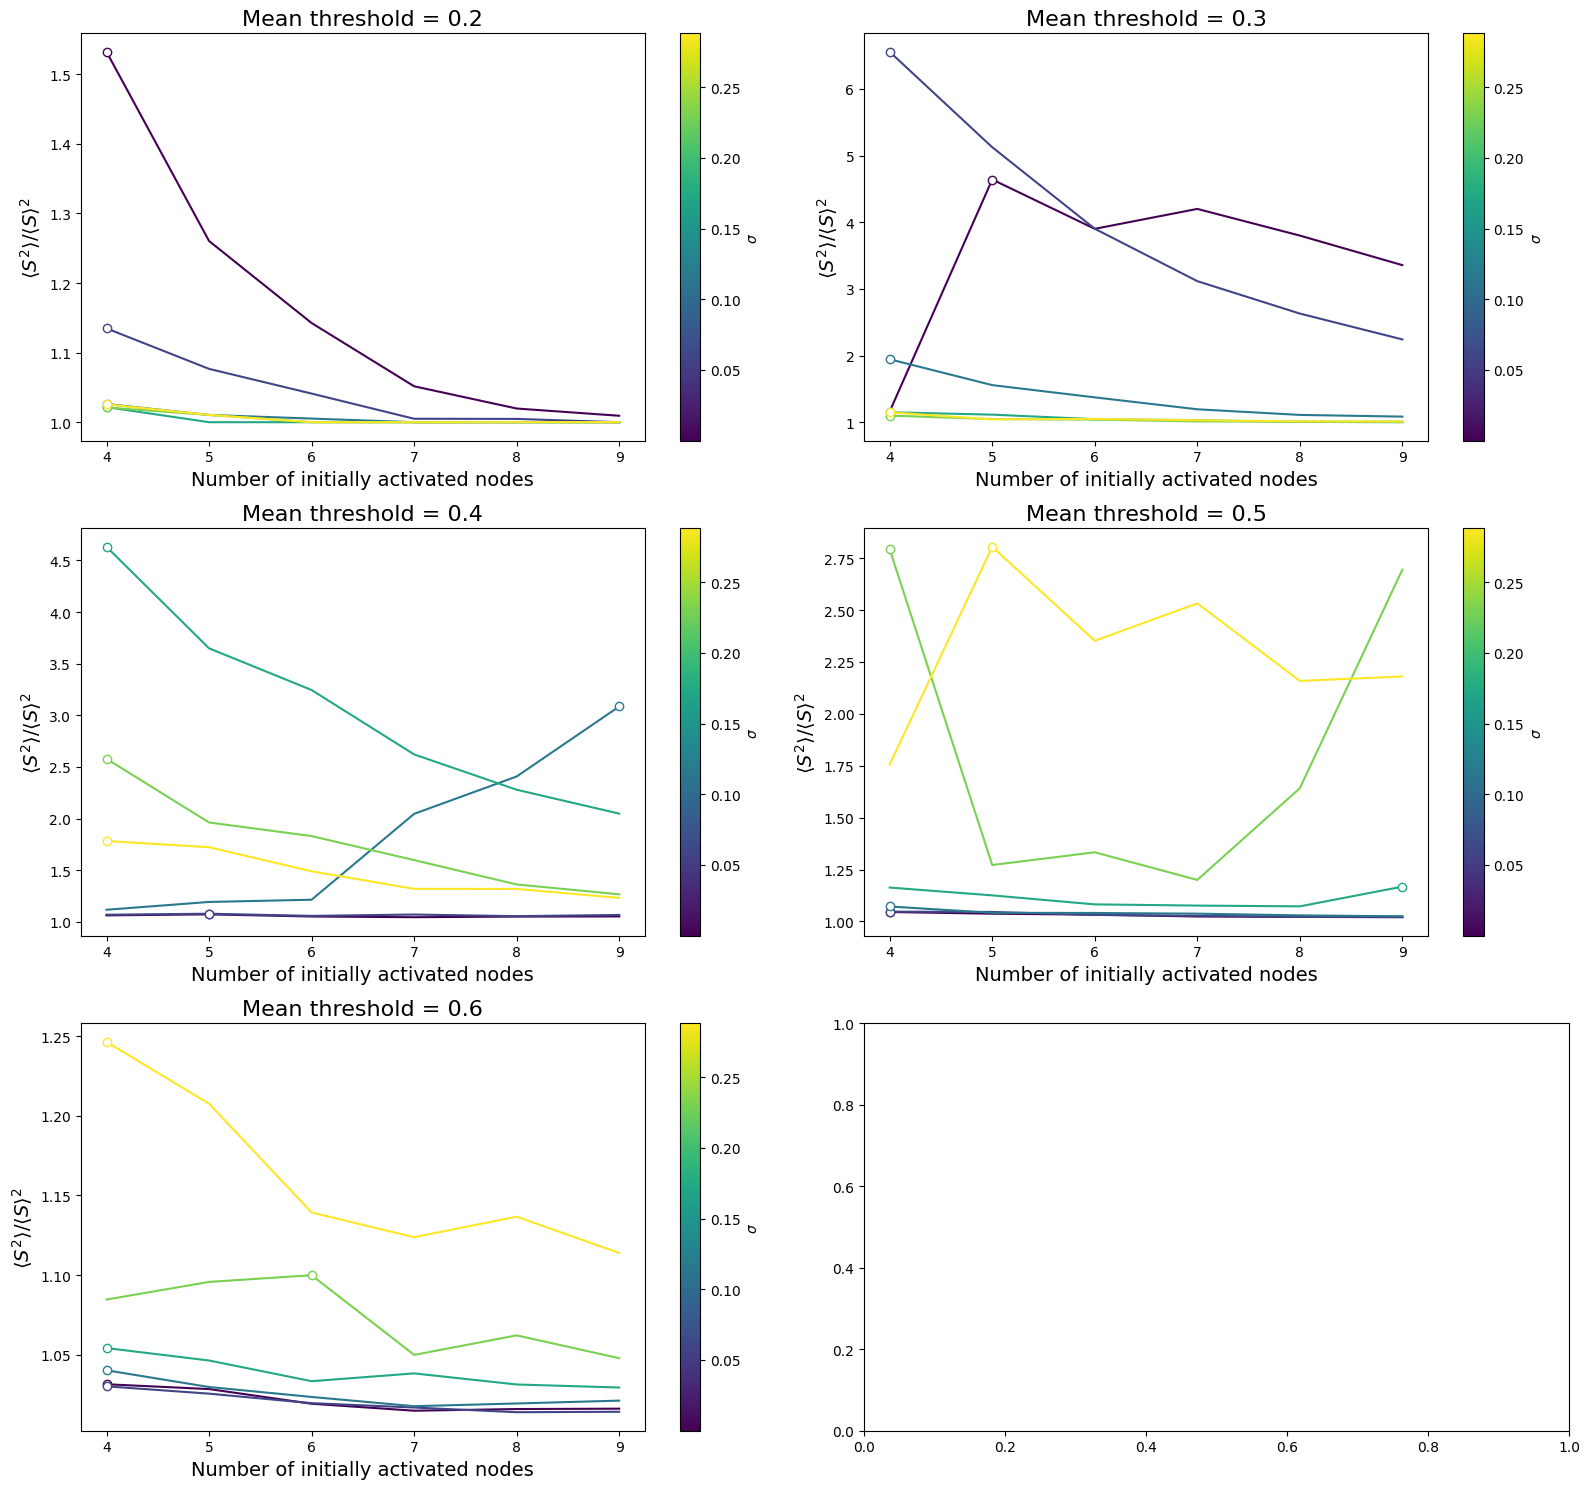

In [3]:
base_dir = "susceptibility_results_discrete"

# Find all mean folders
mean_dirs = sorted(glob.glob(os.path.join(base_dir, "village_mean_*")))

# Setup for subplots
n_means = len(mean_dirs)
n_rows = math.ceil(n_means / 2)
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5*n_rows))
axes = axes.flatten()

# Color bar setup
cmap = plt.cm.viridis

# For fixing all x-axes to same limit
# global_max_fIA = 0

# Each mean gets one graph
for ax, mean_dir in zip(axes, mean_dirs):

    # Setup filenames and sort by std value
    files = sorted(glob.glob(os.path.join(mean_dir, "std_*.pkl")))

    # Load data from files into curves list
    curves = []
    for file in files:
        with open(file, "rb") as f:
            curves.append(pickle.load(f))

    # Normalize std values for colorbar
    std_values = [curve["std"] for curve in curves]
    norm = plt.Normalize(min(std_values), max(std_values))

    for curve in curves:

        std = curve["std"]
        x = curve["n_seeds"]
        y = curve["Sus"]

        sorted_curves = np.argsort(x)
        x = np.array(x)[sorted_curves]
        y = np.array(y)[sorted_curves]

        # Update x-axis limit to max fIA so far 
        # global_max_fIA = max(global_max_fIA, max(curve["fIA"]))

        #P Plot curve
        ax.plot(x, y, color=cmap(norm(std)))

        # Plot peak on curve
        peak = np.argmax(y)
        ax.plot(
            x[peak],
            y[peak],
            "-o",
            color=cmap(norm(std)),
            markerfacecolor="white"
        )

    # Extract mean value for title
    mean_val = os.path.basename(mean_dir).split("_")[-1]

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=ax, label=r"$\sigma$")

    ax.set_title(f"Mean threshold = {mean_val}", fontsize=16)

    ax.set_ylabel(r'$\langle S^2 \rangle / \langle S \rangle^2$', fontsize=14)
    ax.set_xlabel('Number of initially activated nodes', fontsize=14)

""" for ax in axes:
    ax.set_xlim(0, global_max_fIA) """

plt.tight_layout()
plt.show()


## OLD:

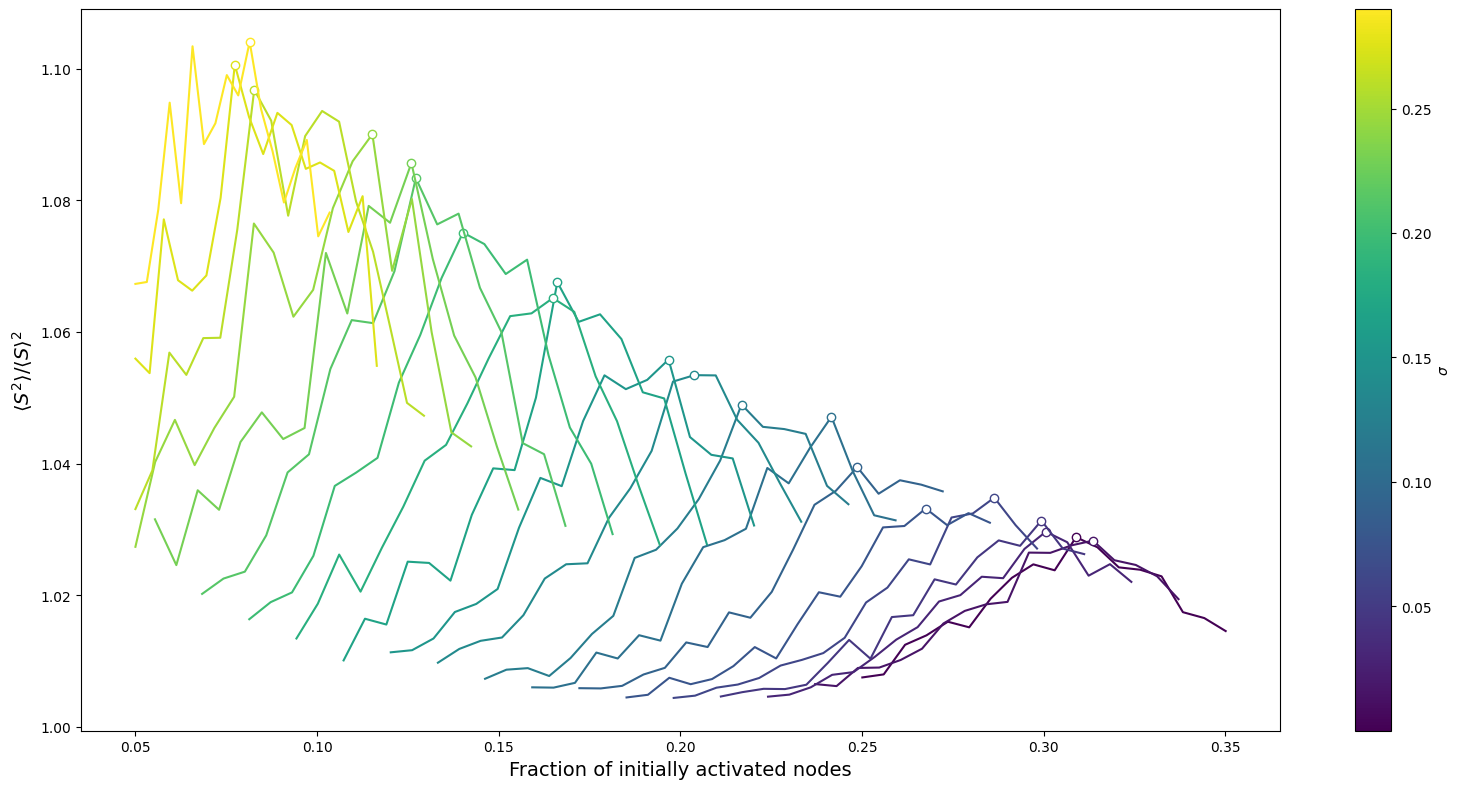

In [ ]:
with open("fb_variance_res.pkl", 'rb') as f:
    data = pickle.load(f, encoding='latin1')

fig, ax = plt.subplots(figsize=(16,8))

stds = sorted(data.keys())
cmap = plt.cm.viridis
norm = plt.Normalize(min(stds), max(stds))

""" for std, curve in data.items():
    x = np.array(curve["fIA"])
    y = np.array(curve["Sus"])

    index = np.argmax(y)

    left = max(0, index - 5)
    right = min (len(x), index + 6)

    x_window = x[left:right]
    y_window = y[left:right]

    ax.plot(x_window, y_window,color=cmap(norm(std)), label=f"{std:.3f}")
    ax.plot(x[index],y[index],'-o',color=cmap(norm(std)),markerfacecolor='white') """

for std, curve in data.items():
    x = curve["fIA"]
    y = curve["Sus"]

    ax.plot(x,y, color=cmap(norm(std)))

    index = y.index(max(y))
    ax.plot(x[index],y[index],'-o',color=cmap(norm(std)),markerfacecolor='white')

#plt.legend(loc=0,frameon=False,ncol=2,fontsize=8)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=ax, label=r"$\sigma$")

ax.set_ylabel(r'$\langle S^2 \rangle / \langle S \rangle^2$', fontsize=14)
ax.set_xlabel('Fraction of initially activated nodes', fontsize=14)

plt.tight_layout()
plt.show()

